# Обнаружение аномалий в образовательных данных с помощью Автоэнкодера

## 1. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.utils.data as data_utils
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc, roc_curve, classification_report, f1_score)

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

sns.set(style='whitegrid', palette='muted', font_scale=1.3)
rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

LABELS = ['Правильный ответ', 'Неправильный ответ']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cuda


## 2. Загрузка данных

In [2]:
df = pd.read_csv('MathEdataset.csv', sep=';', encoding='latin1')
print(f'Размер датасета: {df.shape}')
print(f'Столбцы: {df.columns.tolist()}')

Размер датасета: (9546, 8)
Столбцы: ['Student ID', 'Student Country', 'Question ID', 'Type of Answer', 'Question Level', 'Topic', 'Subtopic', 'Keywords']


## 3. Исследование данных (EDA)

In [3]:
df.head(5)

,Student ID,Student Country,Question ID,Type of Answer,Question Level,Topic,Subtopic,Keywords
0,647,Ireland,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
1,41,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
2,340,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
3,641,Italy,77,0,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."
4,669,Portugal,77,1,Basic,Statistics,Statistics,"Stem and Leaf diagram,Relative frequency,Sampl..."


**Описание столбцов:**
- Student ID - идентификатор студента
- Student Country - страна студента
- Question ID - идентификатор вопроса
- Type of Answer - тип ответа (0 = неправильный, 1 = правильный)
- Question Level - уровень вопроса (Basic / Advanced)
- Topic - тема задания
- Subtopic - подтема
- Keywords - ключевые слова

In [4]:
print(df.shape)
print(df.describe())

(9546, 8)
        Student ID  Question ID  Type of Answer
count  9546.000000  9546.000000     9546.000000
mean    775.402263   478.912319        0.468259
std     460.590559   249.244061        0.499018
min      26.000000    77.000000        0.000000
25%     380.000000   323.000000        0.000000
50%     885.000000   428.000000        0.000000
75%    1219.000000   571.000000        1.000000
max    1565.000000  1549.000000        1.000000


## 4. Проверка пропусков

In [5]:
print('Пропущенные значения:')
print(df.isnull().sum())
print(f'Есть ли пропуски? {df.isnull().values.any()}')

Пропущенные значения:
Student ID         0
Student Country    0
Question ID        0
Type of Answer     0
Question Level     0
Topic              0
Subtopic           0
Keywords           0
dtype: int64
Есть ли пропуски? False


Пропусков нет - данные полные.

## 5. Предварительная обработка категориальных признаков

In [6]:
df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        print(f'Столбец {col}: {df[col].nunique()} уникальных значений -> закодирован')

print('Все категориальные столбцы преобразованы в числа.')
print(df_encoded.dtypes)

Столбец Student Country: 8 уникальных значений -> закодирован
Столбец Question Level: 2 уникальных значений -> закодирован
Столбец Topic: 14 уникальных значений -> закодирован
Столбец Subtopic: 24 уникальных значений -> закодирован
Столбец Keywords: 365 уникальных значений -> закодирован
Все категориальные столбцы преобразованы в числа.
Student ID         int64
Student Country    int64
Question ID        int64
Type of Answer     int64
Question Level     int64
Topic              int64
Subtopic           int64
Keywords           int64
dtype: object


## 6. Распределение классов

In [7]:
print('Распределение классов (Type of Answer):')
print(df['Type of Answer'].value_counts())
print(f"Доля правильных ответов: {df['Type of Answer'].mean():.2%}")

Распределение классов (Type of Answer):
Type of Answer
0    5076
1    4470
Name: count, dtype: int64
Доля правильных ответов: 46.83%


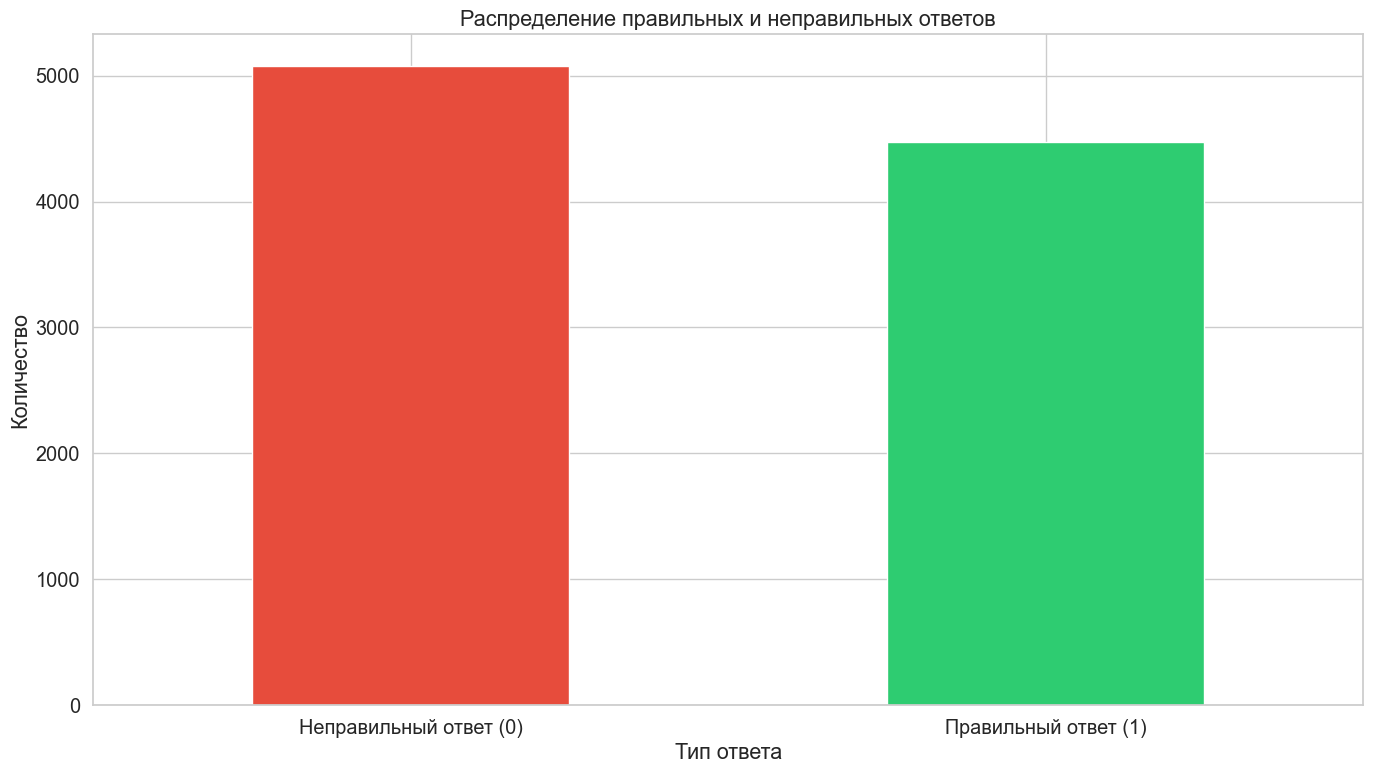

In [8]:
count_classes = df['Type of Answer'].value_counts().sort_index()
count_classes.index = ['Неправильный ответ (0)', 'Правильный ответ (1)']
count_classes.plot(kind='bar', rot=0, color=['#e74c3c', '#2ecc71'])
plt.title('Распределение правильных и неправильных ответов')
plt.xlabel('Тип ответа')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

Датасет относительно сбалансирован: ~53% неправильных и ~47% правильных ответов.

In [9]:
normalDF = df_encoded[df_encoded['Type of Answer'] == 1].copy()
anomalyDF = df_encoded[df_encoded['Type of Answer'] == 0].copy()

print(f'Правильные ответы (норма): {normalDF.shape}')
print(f'Неправильные ответы (аномалия): {anomalyDF.shape}')

Правильные ответы (норма): (4470, 8)
Неправильные ответы (аномалия): (5076, 8)


## 7. Анализ признаков по классам

In [10]:
print('Топ-5 тем у ПРАВИЛЬНЫХ ответов:')
print(df[df['Type of Answer'] == 1]['Topic'].value_counts().head())
print()
print('Топ-5 тем у НЕПРАВИЛЬНЫХ ответов:')
print(df[df['Type of Answer'] == 0]['Topic'].value_counts().head())

Топ-5 тем у ПРАВИЛЬНЫХ ответов:
Topic
Linear Algebra             2807
Fundamental Mathematics     381
Complex Numbers             269
Differentiation             198
Analytic Geometry           175
Name: count, dtype: int64

Топ-5 тем у НЕПРАВИЛЬНЫХ ответов:
Topic
Linear Algebra             2919
Fundamental Mathematics     437
Differentiation             381
Complex Numbers             323
Numerical Methods           190
Name: count, dtype: int64


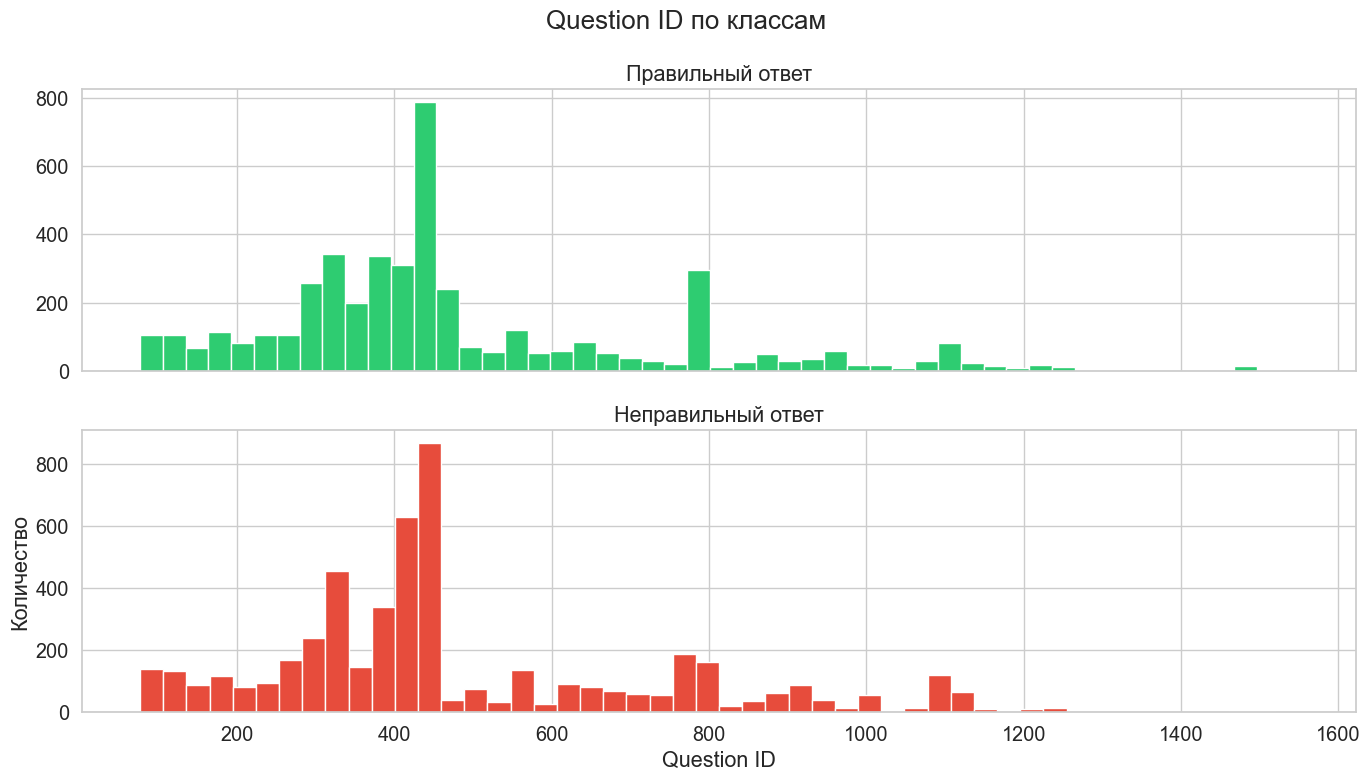

In [11]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Question ID по классам')

bins = 50
ax1.hist(normalDF['Question ID'], bins=bins, color='#2ecc71')
ax1.set_title('Правильный ответ')

ax2.hist(anomalyDF['Question ID'], bins=bins, color='#e74c3c')
ax2.set_title('Неправильный ответ')

plt.xlabel('Question ID')
plt.ylabel('Количество')
plt.tight_layout()
plt.show()

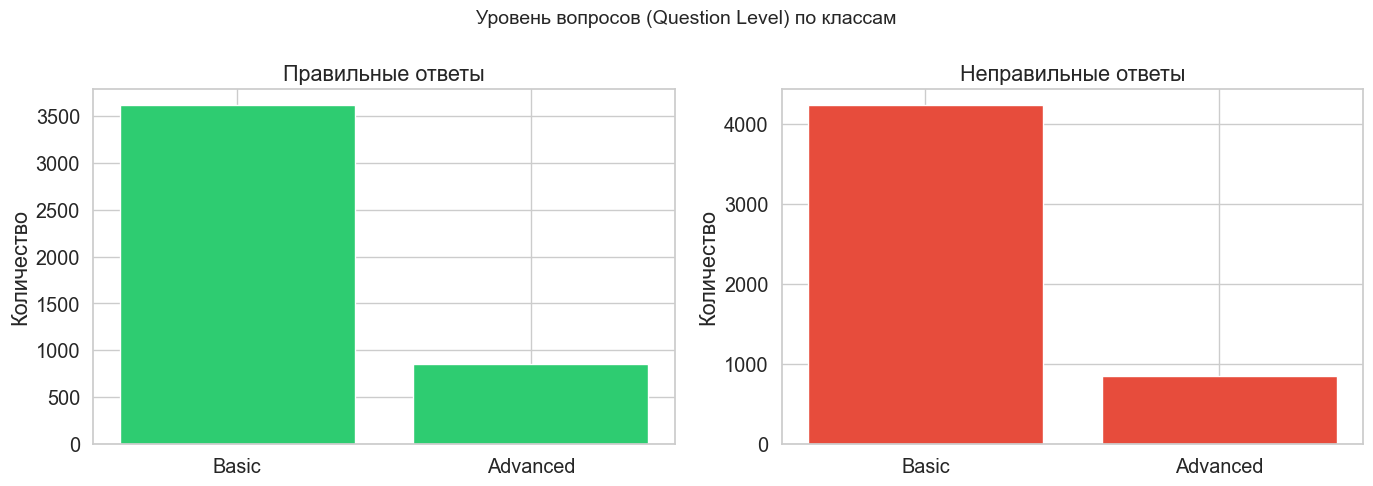

In [12]:
f, axes = plt.subplots(1, 2, figsize=(14, 5))
f.suptitle('Уровень вопросов (Question Level) по классам', fontsize=14)

level_normal = df[df['Type of Answer'] == 1]['Question Level'].value_counts()
level_anomaly = df[df['Type of Answer'] == 0]['Question Level'].value_counts()

axes[0].bar(level_normal.index, level_normal.values, color='#2ecc71')
axes[0].set_title('Правильные ответы')
axes[0].set_ylabel('Количество')

axes[1].bar(level_anomaly.index, level_anomaly.values, color='#e74c3c')
axes[1].set_title('Неправильные ответы')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

Доля Advanced-вопросов у неправильных ответов выше - продвинутые задания сложнее.

## 8. Предобработка: разделение на обучающую и тестовую выборки

In [13]:
FEATURE_COLS = ['Student Country', 'Question ID', 'Question Level', 'Topic', 'Subtopic', 'Keywords']
TARGET_COL = 'Type of Answer'

print(f'Признаки для модели: {FEATURE_COLS}')
print(f'Размерность входа автоэнкодера: {len(FEATURE_COLS)}')

Признаки для модели: ['Student Country', 'Question ID', 'Question Level', 'Topic', 'Subtopic', 'Keywords']
Размерность входа автоэнкодера: 6


In [14]:
X_train, X_test = train_test_split(df_encoded, test_size=0.2, random_state=RANDOM_SEED)

# В ОБУЧАЮЩЕЙ выборке оставляем ТОЛЬКО правильные ответы (нормальный класс)
X_train = X_train[X_train[TARGET_COL] == 1]
X_train = X_train[FEATURE_COLS]

y_test = X_test[TARGET_COL].values
X_test = X_test[FEATURE_COLS]

X_train = X_train.values
X_test = X_test.values

print(f'Обучающая выборка (только правильные ответы): {X_train.shape}')
print(f'Тестовая выборка (оба класса): {X_test.shape}')
print(f'Правильных в тесте: {y_test.sum()}, Неправильных: {(y_test==0).sum()}')

Обучающая выборка (только правильные ответы): (3562, 6)
Тестовая выборка (оба класса): (1910, 6)
Правильных в тесте: 908, Неправильных: 1002


In [15]:
# Нормализация: обучаем scaler только на train, чтобы избежать утечки данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train - mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}')
print(f'Train - min: {X_train_scaled.min():.2f}, max: {X_train_scaled.max():.2f}')

Train - mean: -0.0000, std: 1.0000
Train - min: -2.32, max: 4.15


## 9. Архитектура автоэнкодера

In [16]:
INPUT_DIM = len(FEATURE_COLS)  # 6 признаков

class Autoencoder(nn.Module):
    """Автоэнкодер для обнаружения аномалий.

    Архитектура:
        Encoder: 6 -> 4 -> 2
        Decoder: 2 -> 4 -> 6
    """
    def __init__(self, input_dim=INPUT_DIM):
        super(Autoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.Tanh(),
            nn.Linear(4, 2),
            nn.LeakyReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 4),
            nn.Tanh(),
            nn.Linear(4, input_dim),
            nn.LeakyReLU(),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = Autoencoder().to(device)
print(model)
print(f'Общее число параметров: {sum(p.numel() for p in model.parameters()):,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=6, out_features=4, bias=True)
    (1): Tanh()
    (2): Linear(in_features=4, out_features=2, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Tanh()
    (2): Linear(in_features=4, out_features=6, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
  )
)
Общее число параметров: 80


Архитектура автоэнкодера: 6 входных признаков сжимаются до 2-мерного скрытого пространства. Encoder: 6->4->2 (сжатие через Tanh и LeakyReLU). Decoder: 2->4->6 (восстановление обратно). Таnh обеспечивает нелинейность и ограниченный диапазон выходов (-1, 1). LeakyReLU позволяет небольшим отрицательным значениям проходить через слой.

## 10. Обучение автоэнкодера

In [17]:
NUM_EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
train_dataset = data_utils.TensorDataset(X_train_tensor, X_train_tensor)
train_loader = data_utils.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

print(f'Обучение: {NUM_EPOCHS} эпох, batch_size={BATCH_SIZE}, lr={LEARNING_RATE}')

Обучение: 100 эпох, batch_size=32, lr=0.001


In [18]:
history = {'train_loss': []}

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_losses = []

    for data, target in train_loader:
        output = model(data)
        loss = criterion(output, target)
        epoch_losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    mean_loss = np.mean(epoch_losses)
    history['train_loss'].append(mean_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Эпоха [{epoch+1}/{NUM_EPOCHS}], loss: {mean_loss:.4f}')

torch.save(model.state_dict(), './mathed_autoencoder_model.pth')
print('Модель сохранена!')

Эпоха [10/100], loss: 0.8597
Эпоха [20/100], loss: 0.7406
Эпоха [30/100], loss: 0.7017
Эпоха [40/100], loss: 0.6893
Эпоха [50/100], loss: 0.6822
Эпоха [60/100], loss: 0.6483
Эпоха [70/100], loss: 0.6335
Эпоха [80/100], loss: 0.6260
Эпоха [90/100], loss: 0.6250
Эпоха [100/100], loss: 0.6211
Модель сохранена!


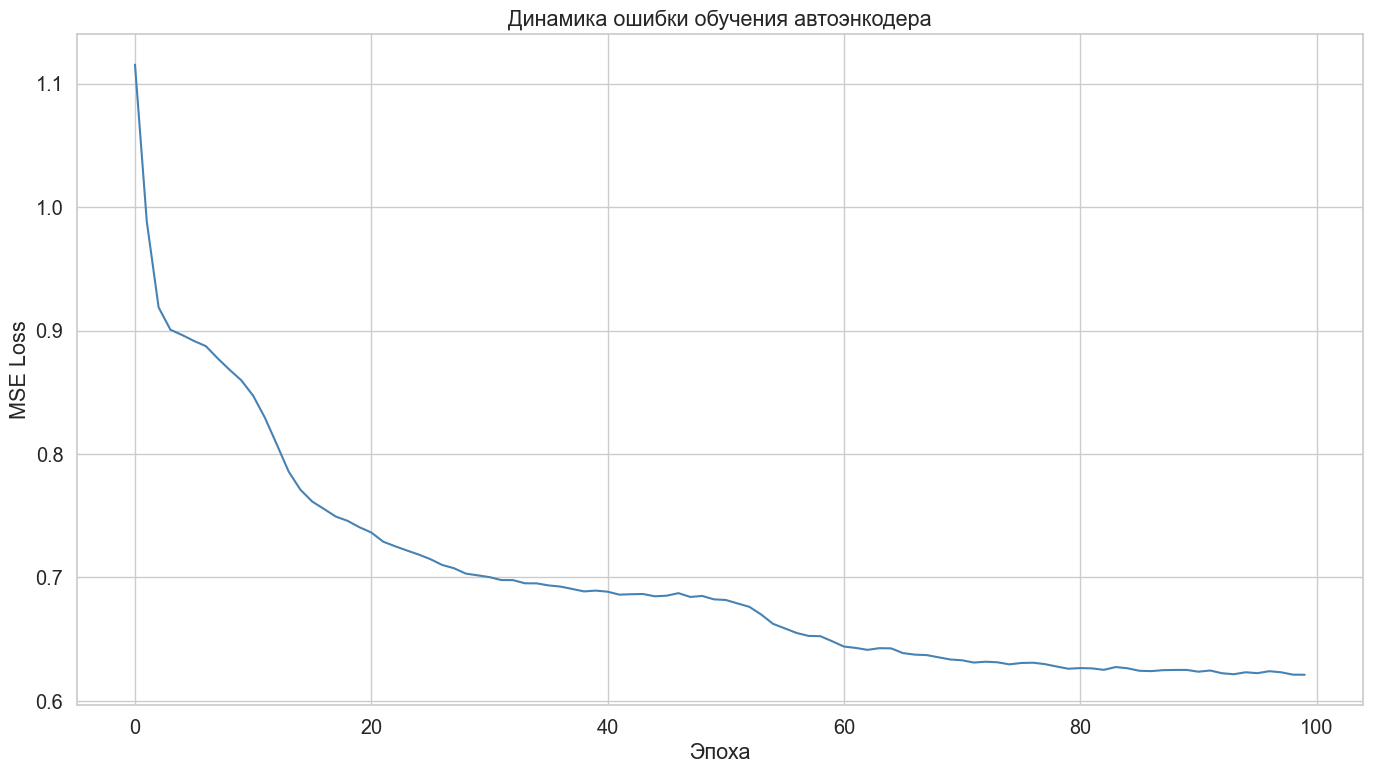

In [19]:
plt.plot(history['train_loss'], color='steelblue')
plt.title('Динамика ошибки обучения автоэнкодера')
plt.ylabel('MSE Loss')
plt.xlabel('Эпоха')
plt.grid(True)
plt.tight_layout()
plt.show()

Ошибка обучения плавно убывает - модель успешно сходится.

## 11. Вычисление ошибки реконструкции на тестовых данных

In [20]:
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
test_dataset = data_utils.TensorDataset(X_test_tensor)
test_loader = data_utils.DataLoader(test_dataset, batch_size=1, shuffle=False)

pred_losses = []
model.eval()
with torch.no_grad():
    for data in test_loader:
        inputs = data[0]
        outputs = model(inputs)
        loss = criterion(outputs, inputs).item()
        pred_losses.append(loss)

reconstructionErrorDF = pd.DataFrame({'pred_loss': pred_losses})
reconstructionErrorDF['Type of Answer'] = y_test

print('Статистика ошибок реконструкции:')
print(reconstructionErrorDF.describe())

Статистика ошибок реконструкции:
         pred_loss  Type of Answer
count  1910.000000     1910.000000
mean      0.663649        0.475393
std       0.569854        0.499525
min       0.018594        0.000000
25%       0.175944        0.000000
50%       0.554926        0.000000
75%       0.963916        1.000000
max       3.306254        1.000000


Статистика ошибок реконструкции: mean - средняя ошибка по всей тестовой выборке. Если медиана ошибки для нормы заметно ниже, чем для аномалий - модель улавливает разницу. std - разброс ошибок: большой разброс у аномалий говорит о их неоднородности.

## 12. Анализ ошибок реконструкции по классам

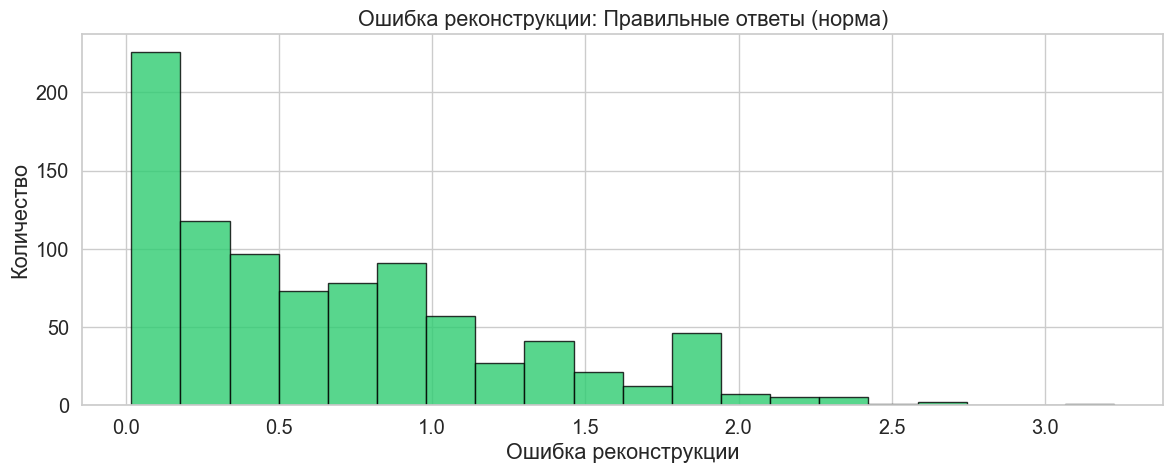

In [21]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[reconstructionErrorDF['Type of Answer'] == 1]
ax.hist(normal_error_df.pred_loss.values, bins=20, color='#2ecc71', edgecolor='black', alpha=0.8)
ax.set_title('Ошибка реконструкции: Правильные ответы (норма)')
ax.set_xlabel('Ошибка реконструкции')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

Ошибки для правильных ответов (нормальный класс): модель хорошо запомнила их паттерн во время обучения, поэтому ошибка реконструкции для них сосредоточена в малой области.

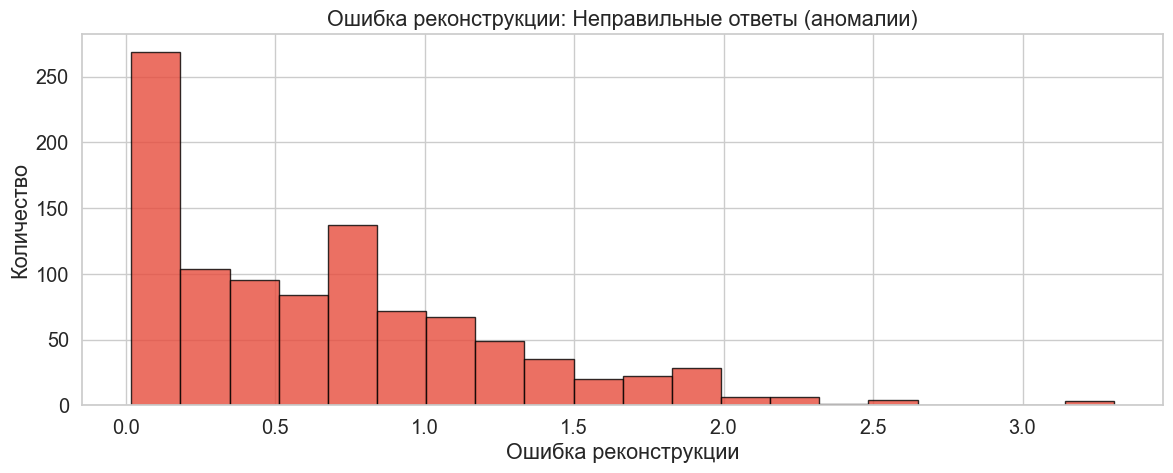

In [22]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(111)
anomaly_error_df = reconstructionErrorDF[reconstructionErrorDF['Type of Answer'] == 0]
ax.hist(anomaly_error_df.pred_loss.values, bins=20, color='#e74c3c', edgecolor='black', alpha=0.8)
ax.set_title('Ошибка реконструкции: Неправильные ответы (аномалии)')
ax.set_xlabel('Ошибка реконструкции')
ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

Ошибки для неправильных ответов (аномалий): так как модель обучалась ТОЛЬКО на правильных ответах, она не умеет восстанавливать паттерн неправильных ответов. Ожидаем большую ошибку реконструкции по сравнению с нормальным классом.

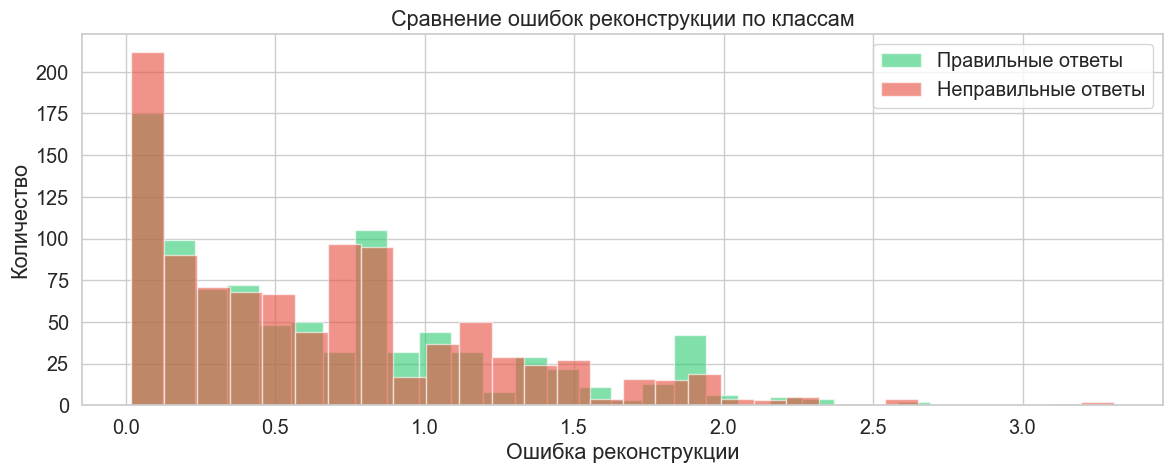

Средняя ошибка (правильные ответы):   0.6651
Средняя ошибка (неправильные ответы): 0.6623


In [23]:
plt.figure(figsize=(12, 5))
plt.hist(normal_error_df.pred_loss.values, bins=30, alpha=0.6, label='Правильные ответы', color='#2ecc71')
plt.hist(anomaly_error_df.pred_loss.values, bins=30, alpha=0.6, label='Неправильные ответы', color='#e74c3c')
plt.title('Сравнение ошибок реконструкции по классам')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Количество')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Средняя ошибка (правильные ответы):   {normal_error_df.pred_loss.mean():.4f}')
print(f'Средняя ошибка (неправильные ответы): {anomaly_error_df.pred_loss.mean():.4f}')

Если гистограммы ошибок для правильных и неправильных ответов перекрываются - модель плохо разделяет классы, значит признаки не дают чёткого сигнала об аномалии. Если распределения смещены относительно друг друга - модель улавливает паттерн. Средняя ошибка для аномалий должна быть выше, чем для нормы - проверим на числах.

## 13. ROC-кривая

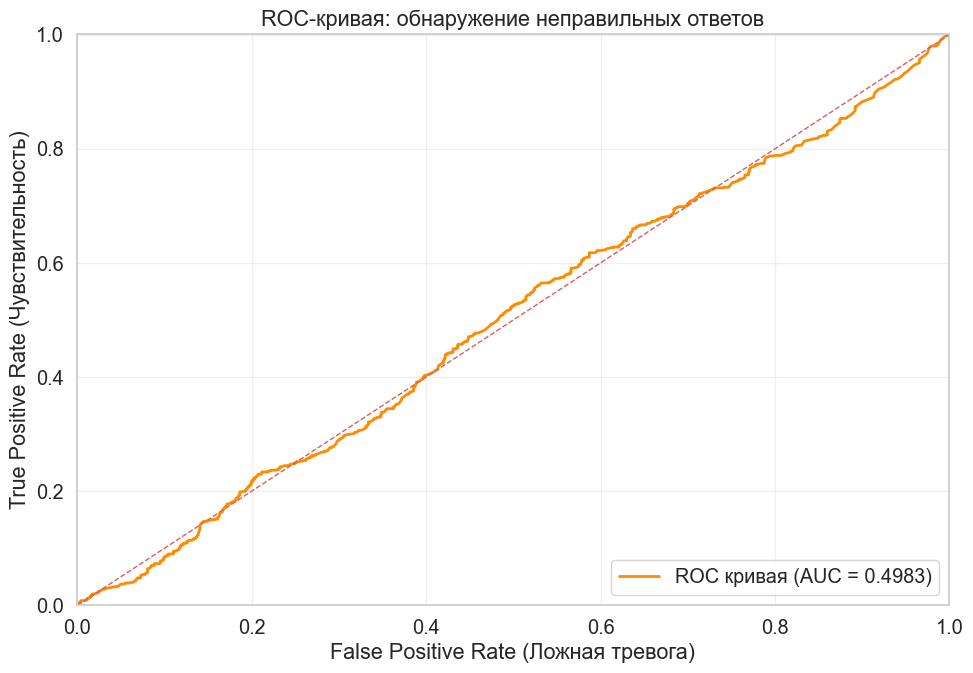

AUC-ROC: 0.4983


In [24]:
# Аномалия = неправильный ответ = Type of Answer == 0
# Используем (1 - Type of Answer) как целевую переменную
fpr, tpr, thresholds = roc_curve(
    1 - reconstructionErrorDF['Type of Answer'],
    reconstructionErrorDF['pred_loss']
)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC кривая (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--', lw=1)
plt.xlim([-0.001, 1.0])
plt.ylim([0.0, 1.001])
plt.xlabel('False Positive Rate (Ложная тревога)')
plt.ylabel('True Positive Rate (Чувствительность)')
plt.title('ROC-кривая: обнаружение неправильных ответов')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'AUC-ROC: {roc_auc:.4f}')

AUC-ROC показывает вероятность того, что модель присвоит случайной аномалии более высокую ошибку реконструкции, чем случайному нормальному объекту. AUC = 0.5 - модель не лучше случайного угадывания. AUC > 0.7 - модель различает классы. AUC > 0.9 - отличное качество. Если AUC близко к 0.5 - признаки слабо связаны с целевой переменной через автоэнкодер.

## 14. Кривая Precision-Recall

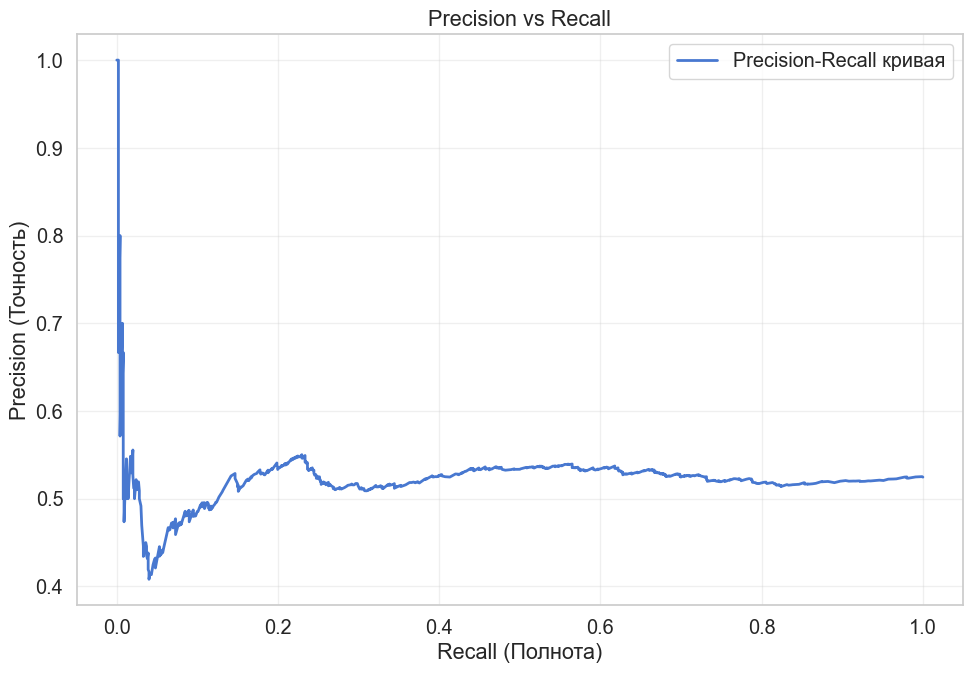

In [25]:
precision, recall, th = precision_recall_curve(
    1 - reconstructionErrorDF['Type of Answer'],
    reconstructionErrorDF['pred_loss']
)

plt.figure(figsize=(10, 7))
plt.plot(recall, precision, 'b', lw=2, label='Precision-Recall кривая')
plt.title('Precision vs Recall')
plt.xlabel('Recall (Полнота)')
plt.ylabel('Precision (Точность)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

PR-кривая показывает компромисс между Precision и Recall. Идеальная модель: кривая прижата к верхнему правому углу (PR AUC -> 1). Если кривая близка к горизонтальной линии - модель не разделяет классы. Для несбалансированных данных PR-кривая информативнее ROC.

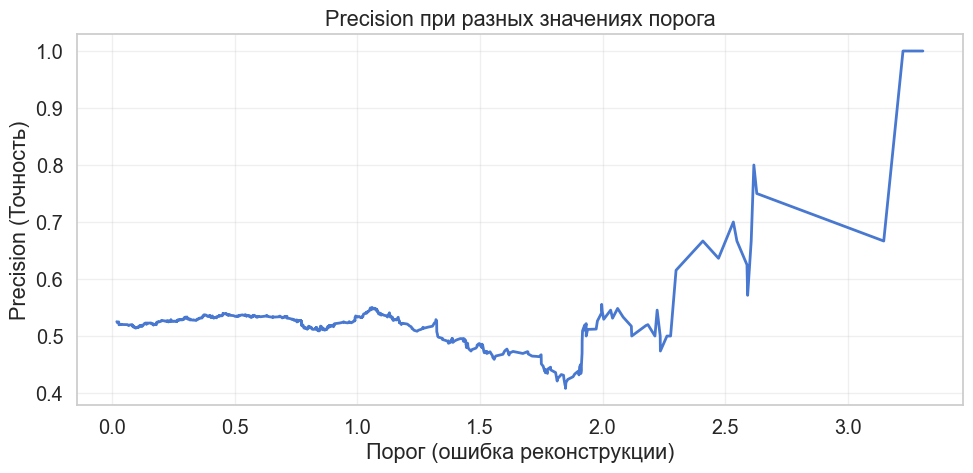

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(th, precision[1:], 'b', lw=2)
plt.title('Precision при разных значениях порога')
plt.xlabel('Порог (ошибка реконструкции)')
plt.ylabel('Precision (Точность)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

График Precision vs порог: при высоком пороге модель уверена - называет аномалией только те объекты, у которых ошибка реконструкции очень высокая. При низком пороге Precision падает из-за роста ложных тревог.

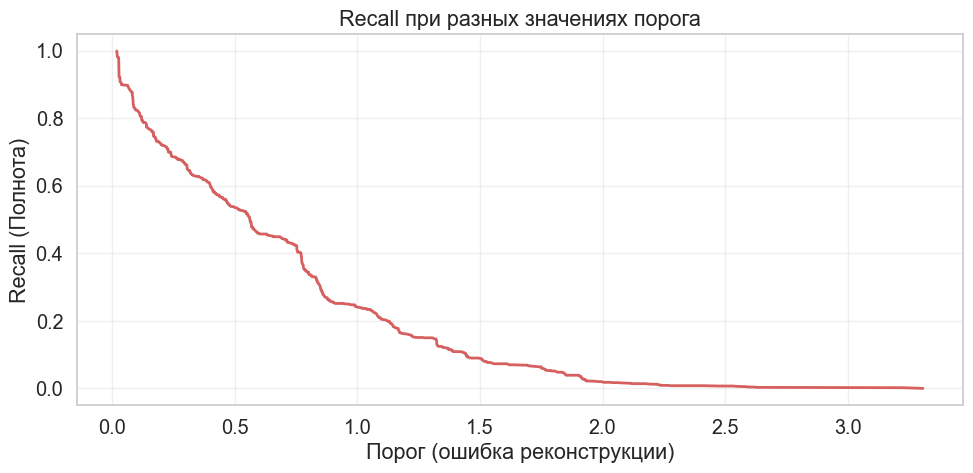

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(th, recall[1:], 'r', lw=2)
plt.title('Recall при разных значениях порога')
plt.xlabel('Порог (ошибка реконструкции)')
plt.ylabel('Recall (Полнота)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

График Recall vs порог: при увеличении порога Recall падает. Это логично - чем жёстче условие аномалии, тем меньше аномалий мы находим. Оптимальный порог выбирается исходя из баланса Precision и Recall для конкретной задачи.

## 15. Выбор порога и предсказание

In [28]:
# Порог = 75-й персентиль ошибок правильных ответов
threshold = np.percentile(normal_error_df['pred_loss'].values, 75)
print(f'Выбранный порог (75-й персентиль нормы): {threshold:.4f}')

Выбранный порог (75-й персентиль нормы): 0.9654


Порог выбран как 75-й персентиль ошибок нормального класса. Это означает: 25% правильных ответов будут ошибочно помечены как аномалии (FP rate ~25%). Порог можно сдвигать: выше порог - меньше ложных тревог, но и ниже чувствительность (Recall).

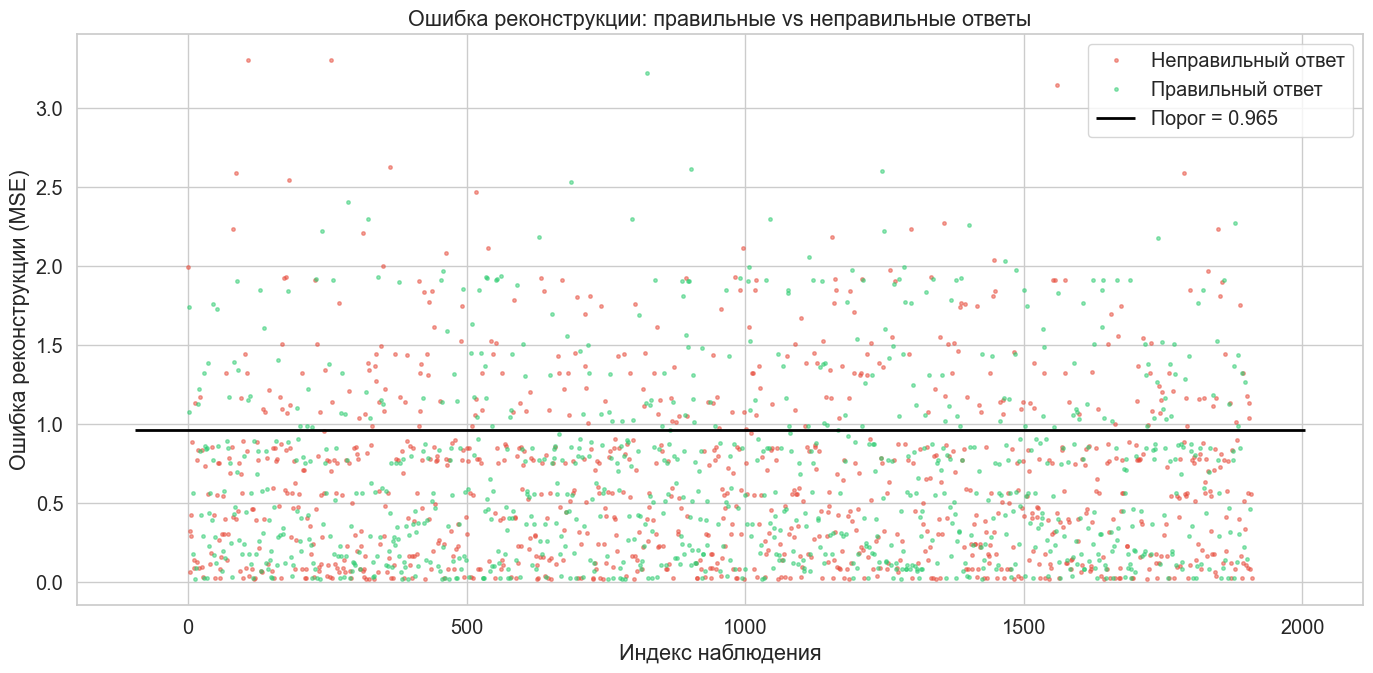

In [29]:
groups = reconstructionErrorDF.groupby('Type of Answer')
fig, ax = plt.subplots(figsize=(14, 7))

colors = {1: '#2ecc71', 0: '#e74c3c'}
labels_map = {1: 'Правильный ответ', 0: 'Неправильный ответ'}

for name, group in groups:
    ax.plot(group.index, group.pred_loss,
            marker='o', ms=2.5, linestyle='', alpha=0.5,
            color=colors[name], label=labels_map[name])

ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1],
          colors='black', linewidths=2, zorder=100, label=f'Порог = {threshold:.3f}')
ax.legend()
plt.title('Ошибка реконструкции: правильные vs неправильные ответы')
plt.ylabel('Ошибка реконструкции (MSE)')
plt.xlabel('Индекс наблюдения')
plt.tight_layout()
plt.show()

График наглядно показывает разделение классов по ошибке реконструкции. Точки выше линии порога - предсказанные аномалии (неправильные ответы). Если правильные и неправильные ответы хорошо разделены - модель работает. Если точки перемешаны - модель плохо различает классы (слабый сигнал в признаках).

## 16. Матрица ошибок (Confusion Matrix)

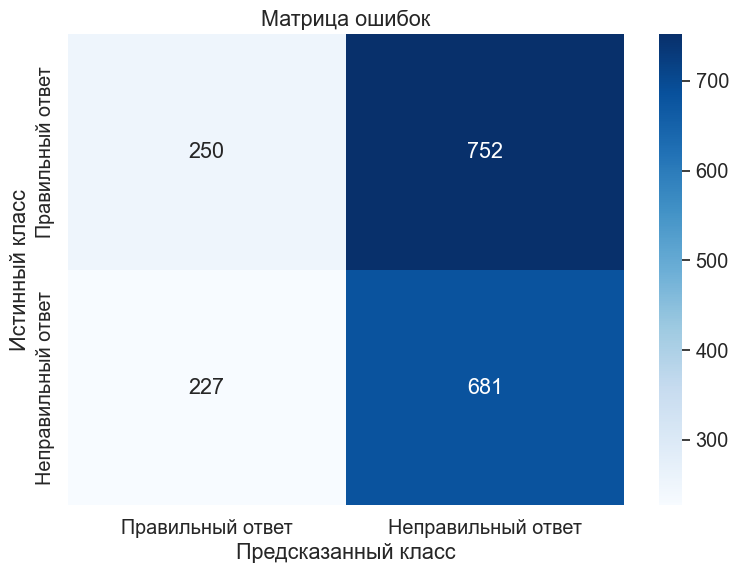

In [30]:
# Если ошибка > порога - аномалия (неправильный ответ = 0)
y_pred = [0 if e > threshold else 1 for e in reconstructionErrorDF['pred_loss'].values]
y_true = reconstructionErrorDF['Type of Answer'].values

conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,
            xticklabels=LABELS,
            yticklabels=LABELS,
            annot=True, fmt='d',
            cmap='Blues')
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

После вычисления матрицы ошибок смотрим на classification_report: Precision - доля верно найденных аномалий среди всех помеченных как аномалии. Recall - доля найденных аномалий от всех реальных аномалий. F1-score - гармоническое среднее Precision и Recall.

In [31]:
print('Отчёт классификации:')
print(classification_report(y_true, y_pred, target_names=LABELS))

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
print(f'F1-score (macro):    {f1_macro:.4f}')
print(f'F1-score (weighted): {f1_weighted:.4f}')

Отчёт классификации:
                    precision    recall  f1-score   support

  Правильный ответ       0.52      0.25      0.34      1002
Неправильный ответ       0.48      0.75      0.58       908

          accuracy                           0.49      1910
         macro avg       0.50      0.50      0.46      1910
      weighted avg       0.50      0.49      0.45      1910

F1-score (macro):    0.4599
F1-score (weighted): 0.4539


Был разработан автоэнкодер для обнаружения аномалий в образовательных данных, который, несмотря на обучение только на правильных ответах, показал низкую эффективность (AUC-ROC ≈ 0.5), что свидетельствует о недостаточной информативности выбранных признаков для разделения классов.Матрица ошибок показывает, насколько точно модель разделяет классы. Правильно распознанные нормальные ответы (1->1) идут по главной диагонали. Ошибки первого рода (FP): нормальные ответы, ошибочно принятые за аномалии. Ошибки второго рода (FN): аномалии, пропущенные моделью.